# Description of the 4 um GC

In [1]:
import autograd.numpy as np 
from autograd.tracer import getval
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web
import pickle

from main import get_coupling_efficiency
N_teeth = 9

15:11:28 EDT WARNING: Using canonical configuration directory at                
             '/Users/dominic/.config/tidy3d'. Found legacy directory at         
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

Some set up variables. Let me know if you have any questions

In [4]:
# Material.
nSi = 3.4487
nSiO2 = 1.4431
nAir = 1.0

# Simulation wavelength.
wl = 1.55  # Central simulation wavelength (um).
bw = .04  # Simulation bandwidth (um).
n_wl = 5  # Number of wavelength points within the bandwidth.

# Geometric parameters.
w_thick = 0.22  # Waveguide thickness (um).
w_width = 0.4  # Waveguide width (um).
w_length = 1.0  # Waveguide length (um).
border_buffer = 0.16 # buffer around the device
N_teeth = 9 # number of teeth in the grating
to_substrate = 2 #thickness of the substrate (um)

#fiber output permaters all initial
source_theta = np.deg2rad(5.0) #angle of the fiber output 
mfd = 4 #mode fiber diameter
source_x = 4+2.5 #x position of the fiber 
src_offset = 2.7  # Distance between the source focus and device (um).
focus_distance = 1.25 #distance between the source and the focus (um)

# Material definition.
mat_Si = td.Medium(permittivity=nSi**2)  # Waveguide material.
mat_SiO2 = td.Medium(permittivity=nSiO2**2)  # SiO2 material.
mat_air = td.Medium(permittivity=nAir**2)  # Air material.

#fabrication parameters
sidewall_angle = 0 #angle of the sidewall
dilation = 0 #dilation of the sidewalls
taper_theta = np.deg2rad(20)

# Wavelengths and frequencies.
wl_max = wl + bw / 2
wl_min = wl - bw / 2
wl_range = np.linspace(wl_min, wl_max, n_wl)
freq = td.C_0 / wl
freqs = td.C_0 / wl_range
freqw = 0.5 * (freqs[0] - freqs[-1])
run_time = 1e-12

# Computational domain size.
pml_spacing = 0.6 * wl
inf_eff = 1000
min_steps_per_wvl = 20

#define the bounds for the parameters
widths_bounds = (0.075, 0.6)
r0_bounds = (1,6)

This cell contains all the funcitons defining the structure and simulation. 

In [5]:
    
def get_centers(widths, r0):
    """
    This function takes in a list of widths and returns a list of centers.

    Args:
        widths (list): A list of widths.
        r0 (float): The radius that the grating starts at.

    Returns:
        list: A list of centers.
    """
    centers = []
    for i in range(len(widths)):
        centers.append(r0+np.sum(widths[:i])+widths[i]/2)
    return centers

def get_tooth_arc(r,w_width=w_width,taper_theta=taper_theta,theta_div=150):
    """
    This resurns the xy values for the tooth arc
    """
    thetas = np.linspace(taper_theta,-taper_theta,theta_div,endpoint=True)
    D = w_width/2/np.tan(taper_theta)
    xs = (D+r)*np.cos(thetas)-D
    ys = (D+r)*np.sin(thetas)
    return np.column_stack((xs,ys))

# ----- structure and simulation builders -----
def make_grating_structure(
    widths,
    to_substrate=to_substrate,
    r0=3,
    N_teeth=N_teeth,
    w_thick=w_thick,
    border_buffer=border_buffer,
    sidewall_angle=sidewall_angle,
    dilation=dilation,
):
    """
    This function makes the grating structure.

    Args:
        widths (list): A list of widths.
        
        to_substrate (float): The thickness of the substrate.
        r0 (float): The radius that the grating starts at.
        N_teeth (int): The number of teeth in the grating.
        sidewall_angle (float): The angle of the sidewall.
        dilation (float): The dilation of the sidewalls.
    """
    #get the centers of the teeth and gaps
    centers = get_centers(widths, r0)

    #create the substrate
    substrate = td.Structure(
            geometry=td.Box.from_bounds((-inf_eff,-inf_eff,-inf_eff),(inf_eff,inf_eff,-to_substrate)),
            medium=mat_Si,
            name='substrate')

    #create the start waveguide
    start_waveguide = td.Structure(
        geometry=td.Box.from_bounds((-inf_eff,-w_width/2,0),
                                    (0,w_width/2,w_thick)),
        medium=mat_Si,
        name='start_waveguide')

    #create the end waveguide
    end_arc = get_tooth_arc(centers[-1]+widths[-1]/2-dilation)
    end_vertices = np.concatenate([
        end_arc,
        np.column_stack((inf_eff,end_arc[-1,1])),
        np.column_stack((inf_eff,end_arc[0,1])),
    ])
    end_waveguide = td.Structure(   
        geometry=td.PolySlab(
        vertices=end_vertices,
        axis=2,
        slab_bounds=(0,w_thick)),
        medium=mat_Si,
        name='top_end_waveguide')

    #create taper 
    x_taper = np.linspace(0, (r0+dilation+w_width/2/np.tan(taper_theta))*np.cos(taper_theta)-w_width/2/np.tan(taper_theta), 500)
    y_taper = np.linspace(w_width/2, (w_width/2/np.tan(taper_theta)+r0+dilation)*np.sin(taper_theta), 500)
    taper_vertices = np.concatenate([
        np.column_stack((x_taper[:-1], y_taper[:-1])),
        get_tooth_arc(r0+dilation),
        np.column_stack((x_taper[:-1][::-1], -y_taper[:-1][::-1]))])
    
    taper = td.Structure(
        geometry=td.PolySlab(
        vertices=taper_vertices,
        axis=2,
        slab_bounds=(0,w_thick)),
        medium=mat_Si,
        name='top_taper')


    #create the air above 
    air = td.Structure(
        geometry=td.Box.from_bounds((-inf_eff,-inf_eff,2.2),
                                    (inf_eff,inf_eff,inf_eff)),
        medium=mat_air,
        name='air')

    #get the centers of the teeth and gaps
    teeth = []
    for i, (center, width) in enumerate(zip(centers, widths)):

        if i % 2 == 1:
            vertices = np.concatenate([
                get_tooth_arc(center-width/2+dilation),
                get_tooth_arc(center+width/2-dilation)[::-1],
            ])
            tooth_geom_gap = td.PolySlab(
                vertices=vertices,
                axis=2,
                slab_bounds=(0,w_thick))
            teeth.append(tooth_geom_gap)
            
    teeth = td.Structure(
            geometry=td.GeometryGroup(geometries=teeth),
            medium=mat_Si,
            name='teeth')

    #define the minumum and maximum x and z bounds
    min_x = -border_buffer-pml_spacing
    max_x = border_buffer+pml_spacing+getval(centers[-1])+getval(widths[-1])/2+getval(dilation)
    min_y = getval(end_arc[-1,1])-border_buffer-pml_spacing
    max_y = getval(end_arc[0,1])+border_buffer+pml_spacing
    min_z = -border_buffer-pml_spacing-getval(to_substrate)
    max_z = 2.2+border_buffer+pml_spacing

    sim_box = td.Box.from_bounds(
        rmin=(min_x,min_y,min_z),
        rmax=(max_x,max_y,max_z),
    )

    structures = [substrate, start_waveguide, end_waveguide, taper, teeth, air]
    return structures, sim_box

def make_sim(
    widths,
    to_substrate=to_substrate,
    r0=3,
    N_teeth=N_teeth,
    w_thick=w_thick,
    border_buffer=border_buffer,
    sidewall_angle=sidewall_angle,
    dilation=dilation,
    source_x=source_x,
    source_y=0,
    source_theta=source_theta,
    mfd=mfd,
    src_offset=src_offset,
    include_field_monitor=False,
    freq=freq,
    freqw=freqw,
    freqs=freqs,
    run_time=run_time,
    pml_spacing=pml_spacing,
    min_steps_per_wvl=min_steps_per_wvl,
    focus_distance=focus_distance,
):  

    """ 
    This function makes the simulation.
    """

    #get the structures
    structures,sim_box = make_grating_structure(widths,
                to_substrate=to_substrate,
                r0=r0,
                N_teeth=N_teeth,
                w_thick=w_thick,
                border_buffer=border_buffer,
                sidewall_angle=sidewall_angle,
                dilation=dilation,
                )
                
    #define the gaussian beam source
    sources = [td.GaussianBeam(
        size=(2 * mfd, 2 * mfd, 0),
        center=[source_x, source_y, w_thick+src_offset],
        source_time=td.GaussianPulse(freq0=freq, fwidth=freqw),
        angle_theta=source_theta,
        direction="-",
        waist_radius=mfd / 2,
        pol_angle=np.pi / 2,  # 90 degree polarization angle for TE polarization
        waist_distance=-focus_distance-src_offset,
    )]

    #define the mode monitor
    monitors = [
        td.ModeMonitor(
        center=(-2*border_buffer, 0, w_thick / 2),
        size=(0, w_width*4, w_thick*4),
        freqs=freqs,
        mode_spec=td.ModeSpec(num_modes=1, target_neff=nSi),
        name="mode",
    )]

    #if we want to include the field monitor
    if include_field_monitor:
        monitors.append(
            td.FieldMonitor(
                center=(0, 0, 0),
                size=(inf_eff, inf_eff, inf_eff),
                freqs=freq,
                name="field",
            )
        )

    if source_y == 0:
        symmetry = (0, -1, 0)
    else:
        symmetry = (0,0,0)
        
    sim = td.Simulation(
        center=sim_box.center,
        size=sim_box.size,
        grid_spec=td.GridSpec.auto(min_steps_per_wvl=min_steps_per_wvl),
        structures=structures,
        sources=sources,
        monitors=monitors,
        run_time=run_time,
        medium=mat_SiO2,
        boundary_spec=td.BoundarySpec(
            x=td.Boundary.pml(),
            y=td.Boundary.pml(),
            z=td.Boundary.pml(),
        ),
        symmetry=symmetry
    )
    return sim


## This section we will show the basic simulation set up 

In [11]:
# first import the variables from the optimization data file 
with open('data/3d_opt/tmp.pkl', 'rb') as f:
    data = pickle.load(f)

widths = data['params'][:-1]
r0 = data['params'][-1]
print(len(widths))
print(widths,r0)


20
[0.10171423 0.56965874 0.10788232 0.55931574 0.12239918 0.54603395
 0.14365081 0.53730965 0.17286603 0.52794493 0.19726445 0.51377853
 0.20126376 0.49329495 0.21203213 0.45472557 0.18517969 0.42768282
 0.25428672 0.4253686 ] 4.4967401101567175


4.4967401101567175


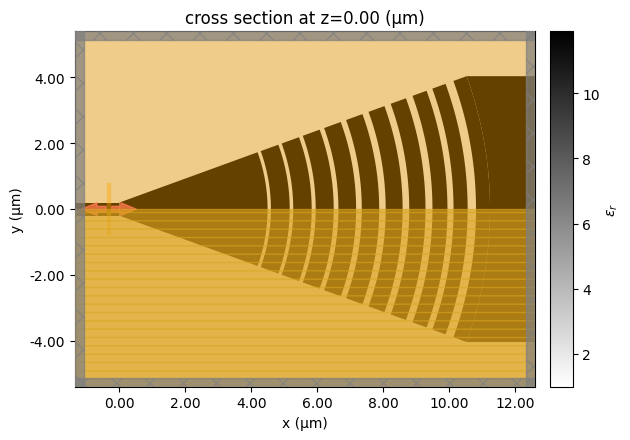

In [20]:
#now we set up the simulation 
sim = make_sim(widths, r0=r0, include_field_monitor=True)
sim.plot_eps(z=0)
print(r0)
plt.show()

In [13]:
#run the simulation 
sim_data = web.run(sim, task_name="GC4um_3D_SIO", verbose=False, path='/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_3D_4um_Si/data/tidy3d_output/tmp.hdf5')

0.2667394616662983


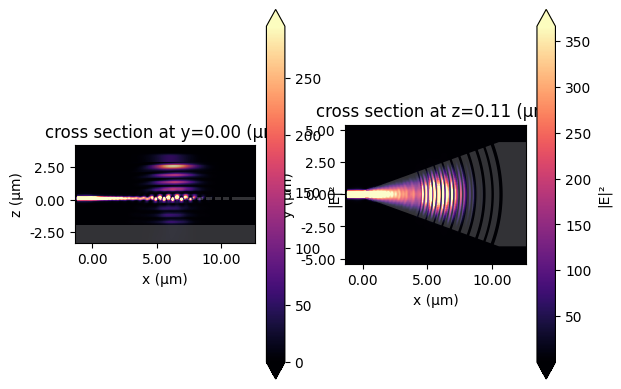

In [19]:
#print the coupling at 1550 and show the field 
print(get_coupling_efficiency(sim_data)[n_wl//2])
fig, ax = plt.subplots(1,2)
sim_data.plot_field('field','E','abs^2',y=0,ax=ax[0])
sim_data.plot_field('field','E','abs^2',z=.11,ax=ax[1])
plt.show()